# 🌾 Projet Force N - Système de Recommandation de Cultures

## 📋 Description du projet

Ce projet implémente un système complet de prédiction de cultures agricoles basé sur les caractéristiques du sol et les conditions climatiques.

### Objectifs
- Prédire la culture la plus adaptée à partir de 7 paramètres (N, P, K, température, humidité, pH, pluviométrie)
- Comparer plusieurs modèles de machine learning
- Fournir une interface utilisateur intuitive

### Structure du projet
1. **Phase 1** : Analyse et prétraitement des données
2. **Phase 2** : Modélisation et sélection du meilleur modèle
3. **Phase 3** : Déploiement avec une interface Gradio

---

# 📊 Phase 1 : Analyse et Prétraitement des Données

## 1. Installation des bibliothèques

In [ ]:
# 1. Installation des bibliothèques
!pip install gradio xgboost



## 2. Import des bibliothèques

In [1]:
# Bibliothèques de manipulation de données
import pandas as pd
import numpy as np




In [2]:
# Bibliothèques de visualisation
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Bibliothèques de machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                            f1_score, precision_score, recall_score, roc_auc_score)


In [4]:
# Utilitaires
import joblib
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Bibliothèque Gradio
import gradio as gr

In [6]:
# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



## 3. Chargement et exploration des données

Le dataset `Crop_recommendation` contient 2200 échantillons avec 7 caractéristiques :
- **N** : Azote (kg/ha)
- **P** : Phosphore (kg/ha)  
- **K** : Potassium (kg/ha)
- **temperature** : Température (°C)
- **humidity** : Humidité (%)
- **ph** : pH du sol
- **rainfall** : Pluviométrie (mm)
- **label** : Type de culture (22 classes différentes)

In [7]:
# 2. Téléchargement du dataset
!kaggle datasets download -d atharvaingle/crop-recommendation-dataset
!unzip -o crop-recommendation-dataset.zip



Dataset URL: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset
License(s): apache-2.0
100% 63.7k/63.7k [00:00<00:00, 45.3MB/s]

Archive:  crop-recommendation-dataset.zip
  inflating: Crop_recommendation.csv  


In [8]:
# 3. Chargement des données
df = pd.read_csv('Crop_recommendation.csv')
print("=== DATASET CROP RECOMMENDATION ===")
print(f"Shape: {df.shape}")
print(f"Colonnes: {df.columns.tolist()}")
print("\nAperçu des données:")
display(df.head())

=== DATASET CROP RECOMMENDATION ===
Shape: (2200, 8)
Colonnes: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Aperçu des données:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 4. Analyse exploratoire des données (EDA)

### 4.1 Statistiques descriptives

In [9]:
print("\n" + "=" * 60)
print("📈 STATISTIQUES DESCRIPTIVES")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("🌾 INFORMATIONS SUR LES CULTURES")
print("=" * 60)
print(f"Nombre de cultures différentes: {df['label'].nunique()}")
print(f"Liste des cultures: {sorted(df['label'].unique())}")

# Distribution des cultures
culture_counts = df['label'].value_counts()
print("\nDistribution:")
print(culture_counts)


📈 STATISTIQUES DESCRIPTIVES
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117 

### 4.2 Visualisation de la distribution des cultures

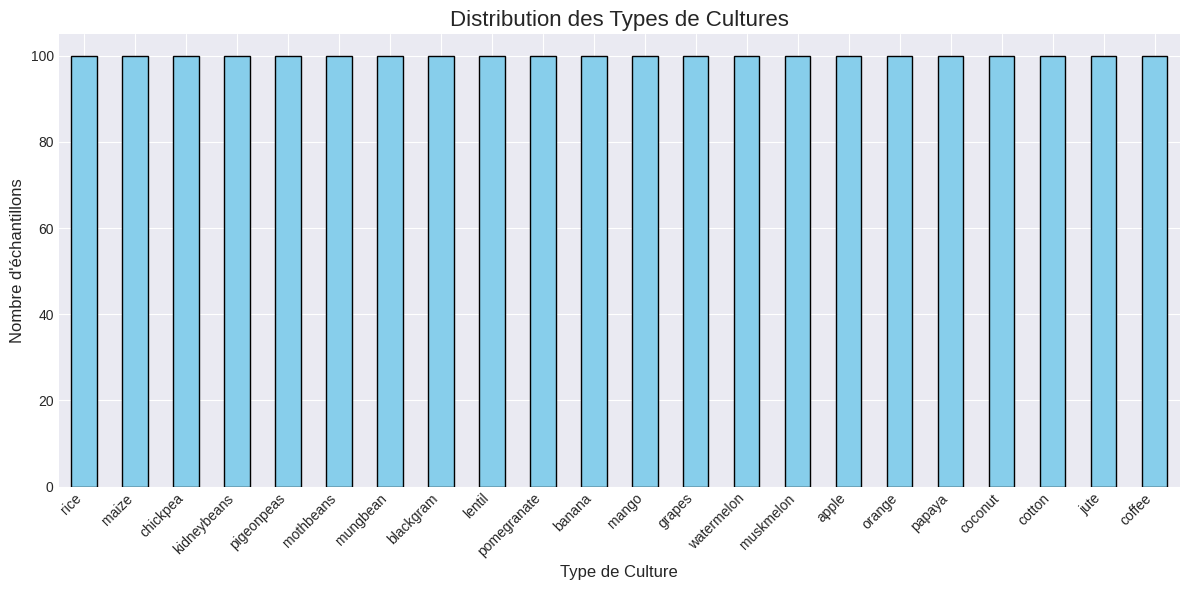

In [10]:
# Visualisation
plt.figure(figsize=(12, 6))
culture_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution des Types de Cultures', fontsize=16)
plt.xlabel('Type de Culture', fontsize=12)
plt.ylabel("Nombre d'échantillons", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('culture_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Distribution des variables numériques

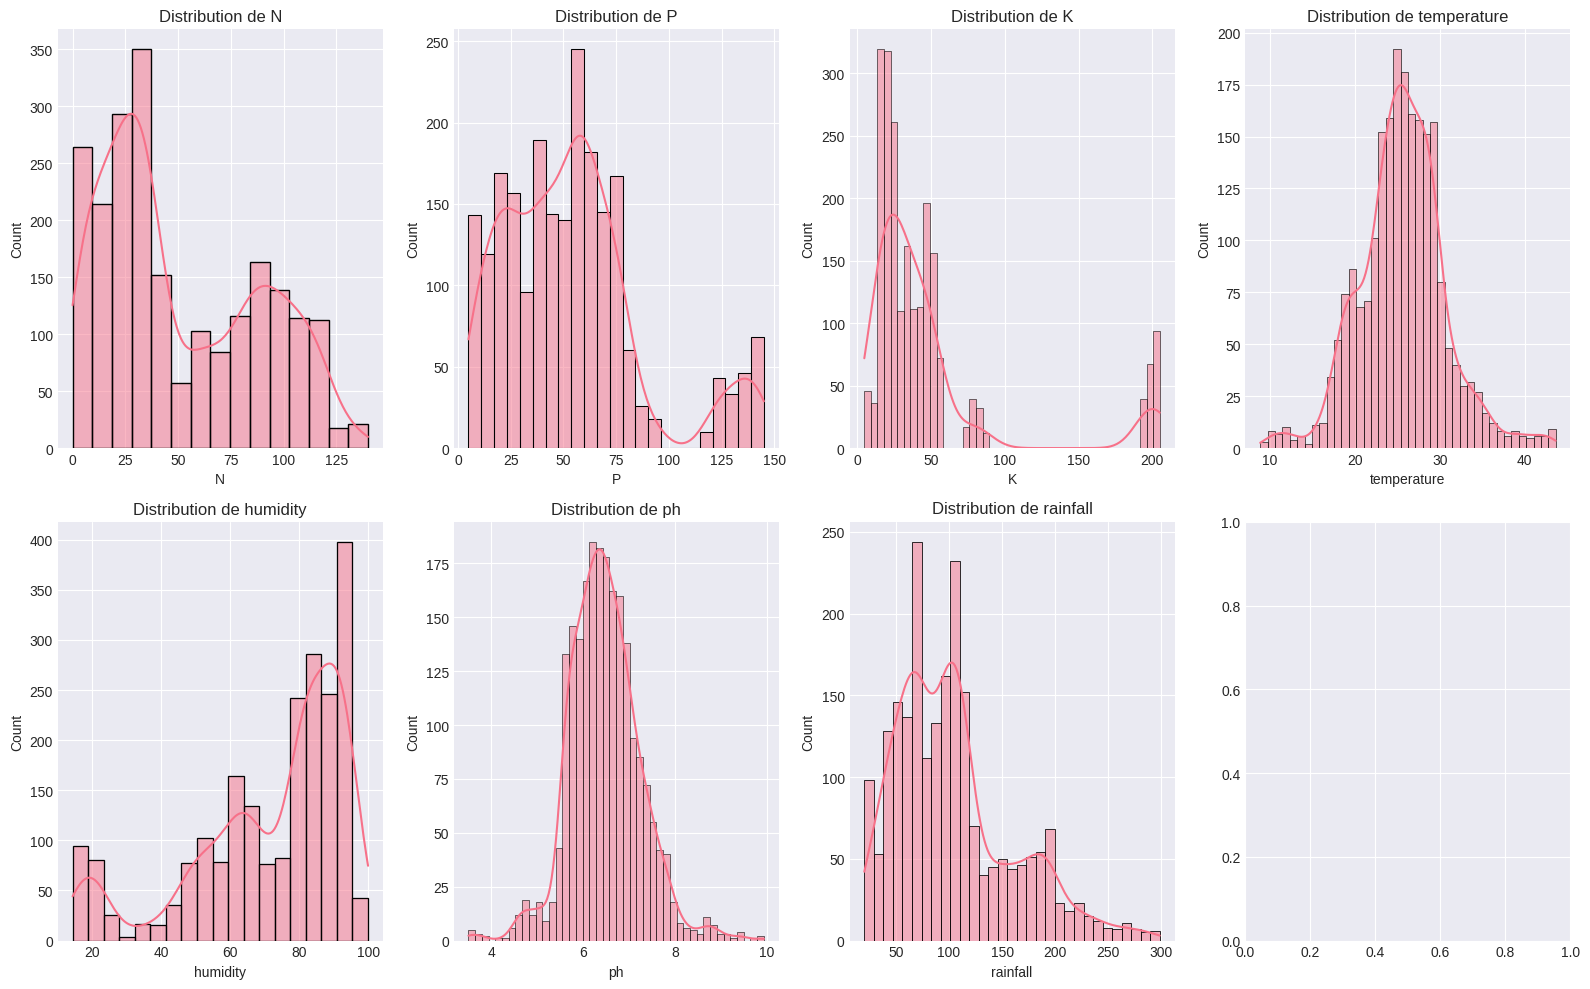

In [11]:
# 3. Distribution des variables numériques
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(df.columns[:-1]):  # Exclure 'label'
    sns.histplot(df[col], kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution de {col}', fontsize=12)
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
plt.show()



### 4.4 Boxplots par culture

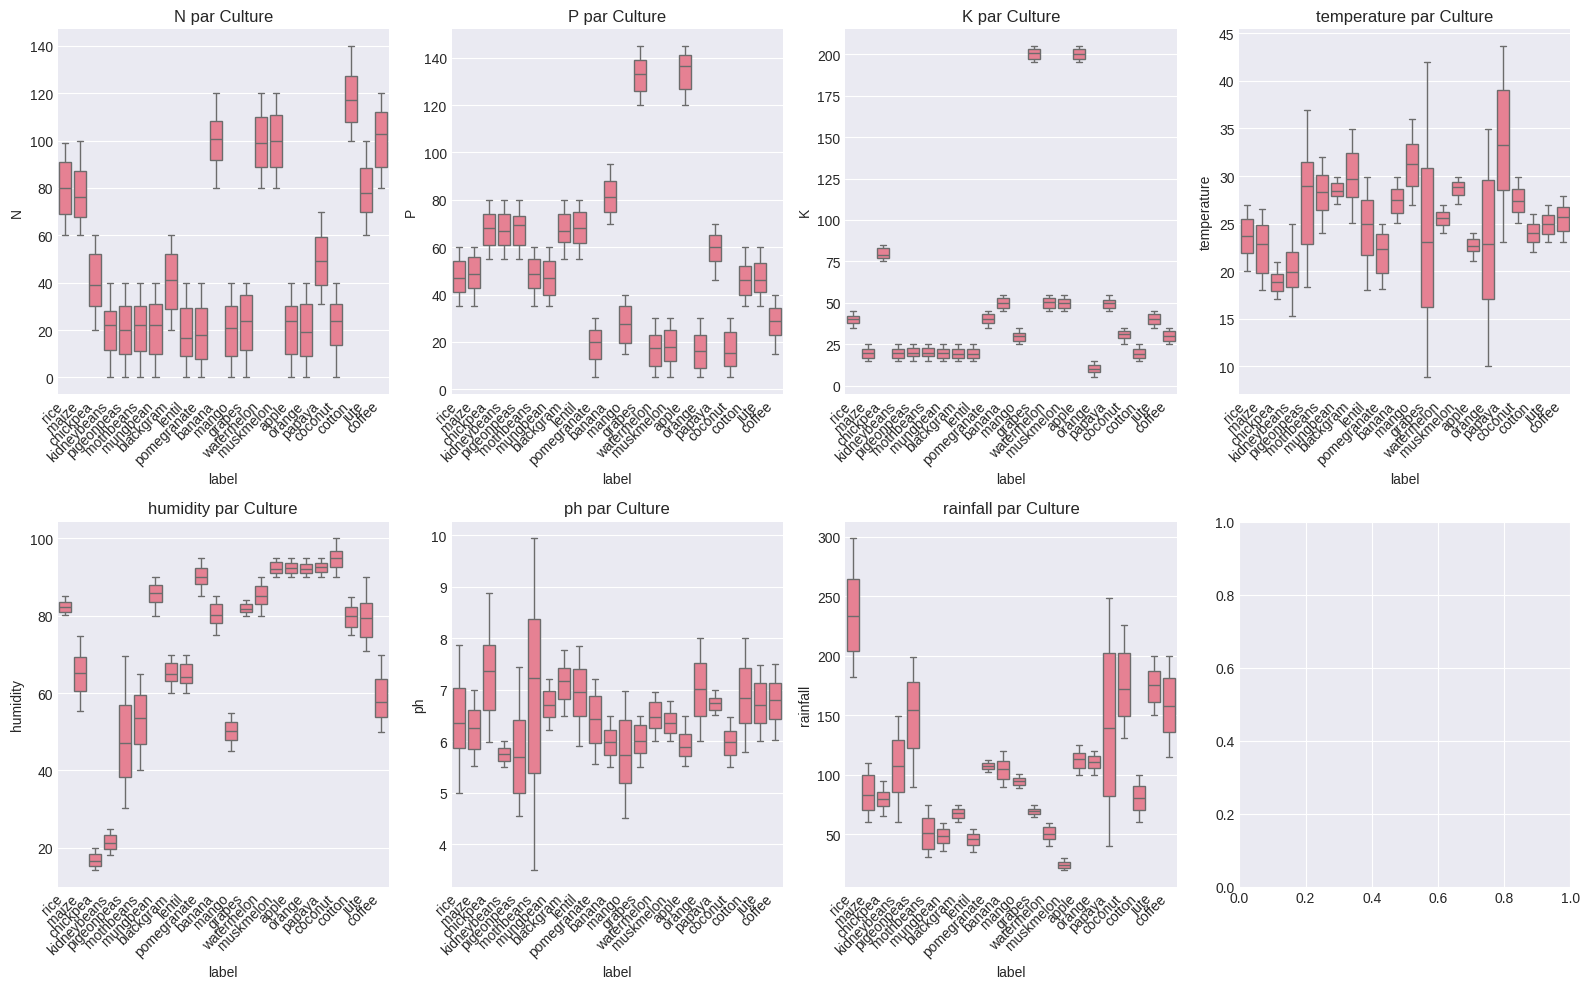

In [12]:
# 4. Boxplots par culture
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(df.columns[:-1]):
    sns.boxplot(data=df, x='label', y=col, ax=axes[idx])
    axes[idx].set_title(f'{col} par Culture', fontsize=12)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('boxplots_by_culture.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Analyse des corrélations

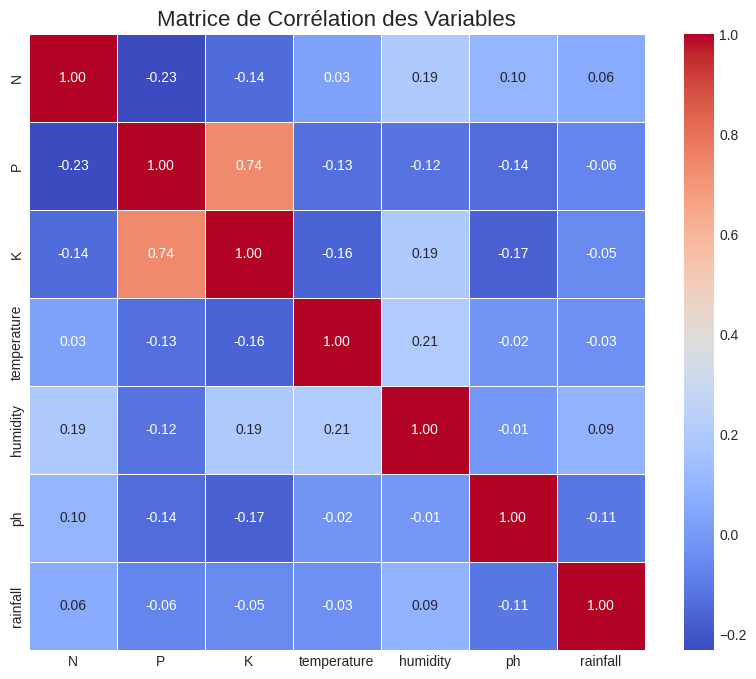


=== MOYENNES DES VARIABLES PAR CULTURE ===
                  N       P       K  temperature  humidity    ph  rainfall
label                                                                     
apple         20.80  134.22  199.89        22.63     92.33  5.93    112.65
banana       100.23   82.01   50.05        27.38     80.36  5.98    104.63
blackgram     40.02   67.47   19.24        29.97     65.12  7.13     67.88
chickpea      40.09   67.79   79.92        18.87     16.86  7.34     80.06
coconut       21.98   16.93   30.59        27.41     94.84  5.98    175.69
coffee       101.20   28.74   29.94        25.54     58.87  6.79    158.07
cotton       117.77   46.24   19.56        23.99     79.84  6.91     80.40
grapes        23.18  132.53  200.11        23.85     81.88  6.03     69.61
jute          78.40   46.86   39.99        24.96     79.64  6.73    174.79
kidneybeans   20.75   67.54   20.05        20.12     21.61  5.75    105.92
lentil        18.77   68.36   19.41        24.51     64.

In [13]:
plt.figure(figsize=(10, 8))
corr_matrix = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Matrice de Corrélation des Variables', fontsize=16)
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Moyennes par culture
print("\n=== MOYENNES DES VARIABLES PAR CULTURE ===")
group_stats = df.groupby('label').mean().round(2)
print(group_stats)

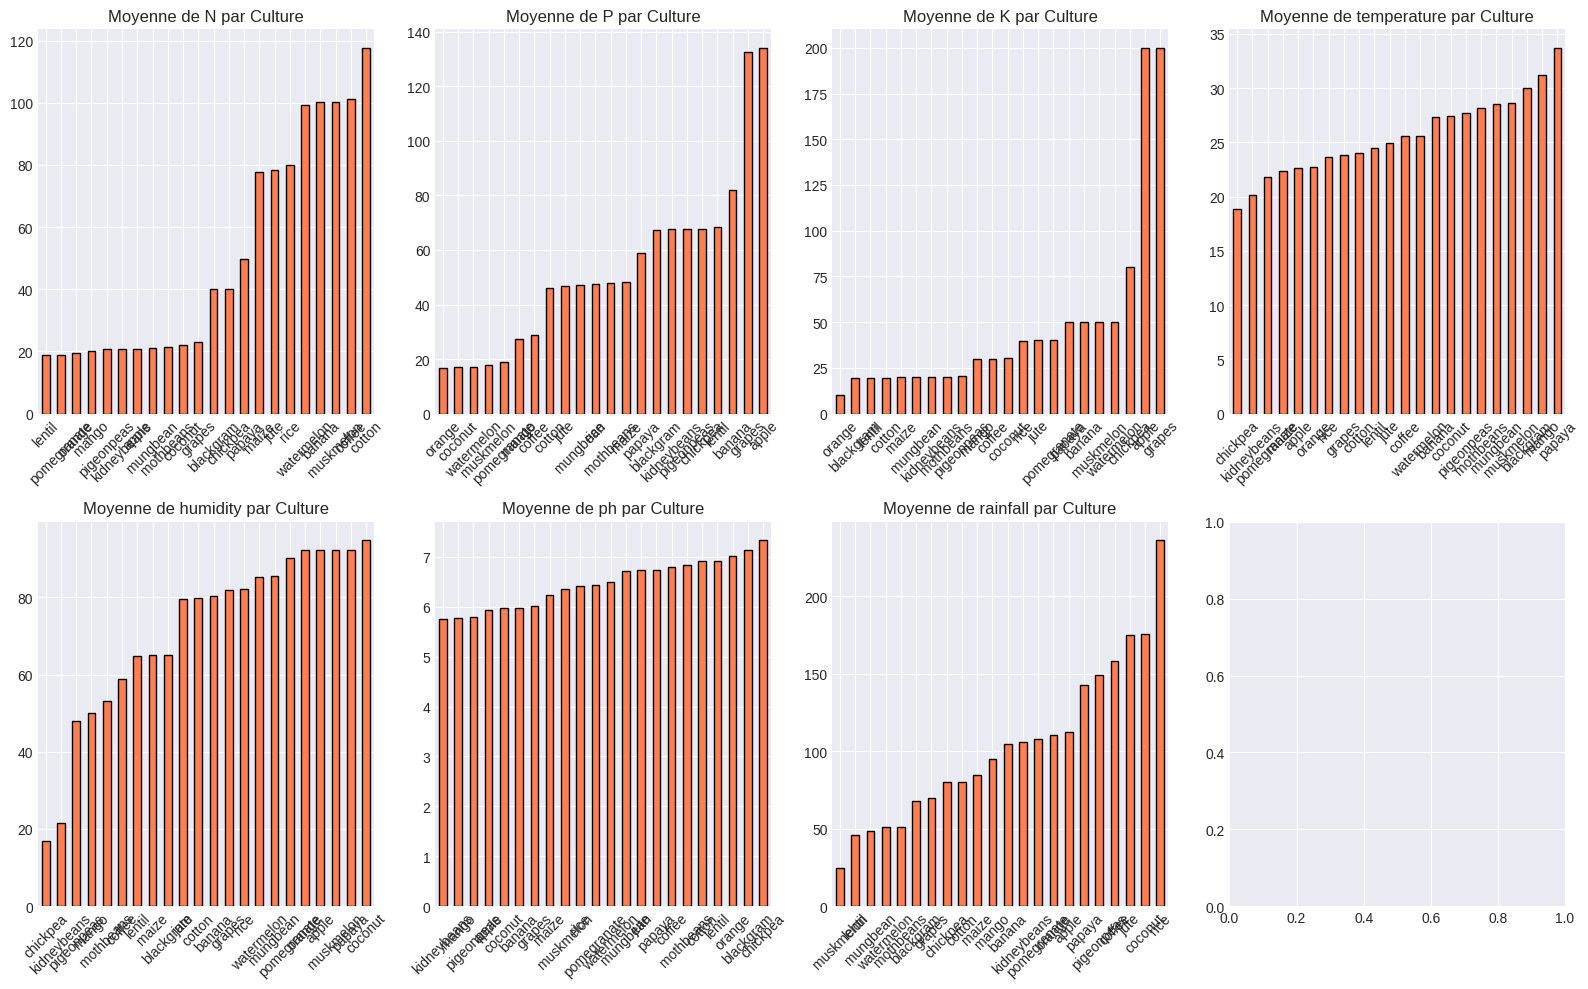

In [14]:
# 3. Visualisation des conditions optimales par culture
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(df.columns[:-1]):
    # Moyenne par culture
    means = df.groupby('label')[col].mean().sort_values()
    means.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
    axes[idx].set_title(f'Moyenne de {col} par Culture', fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('means_by_culture.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Prétraitement des données

### 6.1 Séparation features/target et encodage des labels

In [15]:
# 1. Séparation des features (X) et target (y)
X = df.drop('label', axis=1)
y = df['label']

print("=== DONNÉES INITIALES ===")
print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

# 2. Encodage des labels (conversion des noms de cultures en nombres)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Sauvegarder le mapping pour le déploiement
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\n=== MAPPING DES CULTURES ===")
for culture, code in label_mapping.items():
    print(f"{culture}: {code}")

=== DONNÉES INITIALES ===
Features: (2200, 7)
Target: (2200,)

=== MAPPING DES CULTURES ===
apple: 0
banana: 1
blackgram: 2
chickpea: 3
coconut: 4
coffee: 5
cotton: 6
grapes: 7
jute: 8
kidneybeans: 9
lentil: 10
maize: 11
mango: 12
mothbeans: 13
mungbean: 14
muskmelon: 15
orange: 16
papaya: 17
pigeonpeas: 18
pomegranate: 19
rice: 20
watermelon: 21


### 6.2 Détection des outliers

In [16]:
def detect_outliers_iqr(data, column):
    """Détecte les outliers avec la méthode IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])

print("\n=== DÉTECTION DES OUTLIERS ===")
for col in X.columns:
    count = detect_outliers_iqr(X, col)
    print(f"{col}: {count} outliers ({count/len(X)*100:.2f}%)")


=== DÉTECTION DES OUTLIERS ===
N: 0 outliers (0.00%)
P: 138 outliers (6.27%)
K: 200 outliers (9.09%)
temperature: 86 outliers (3.91%)
humidity: 30 outliers (1.36%)
ph: 57 outliers (2.59%)
rainfall: 100 outliers (4.55%)


## 6.3 Visualisation des outliers

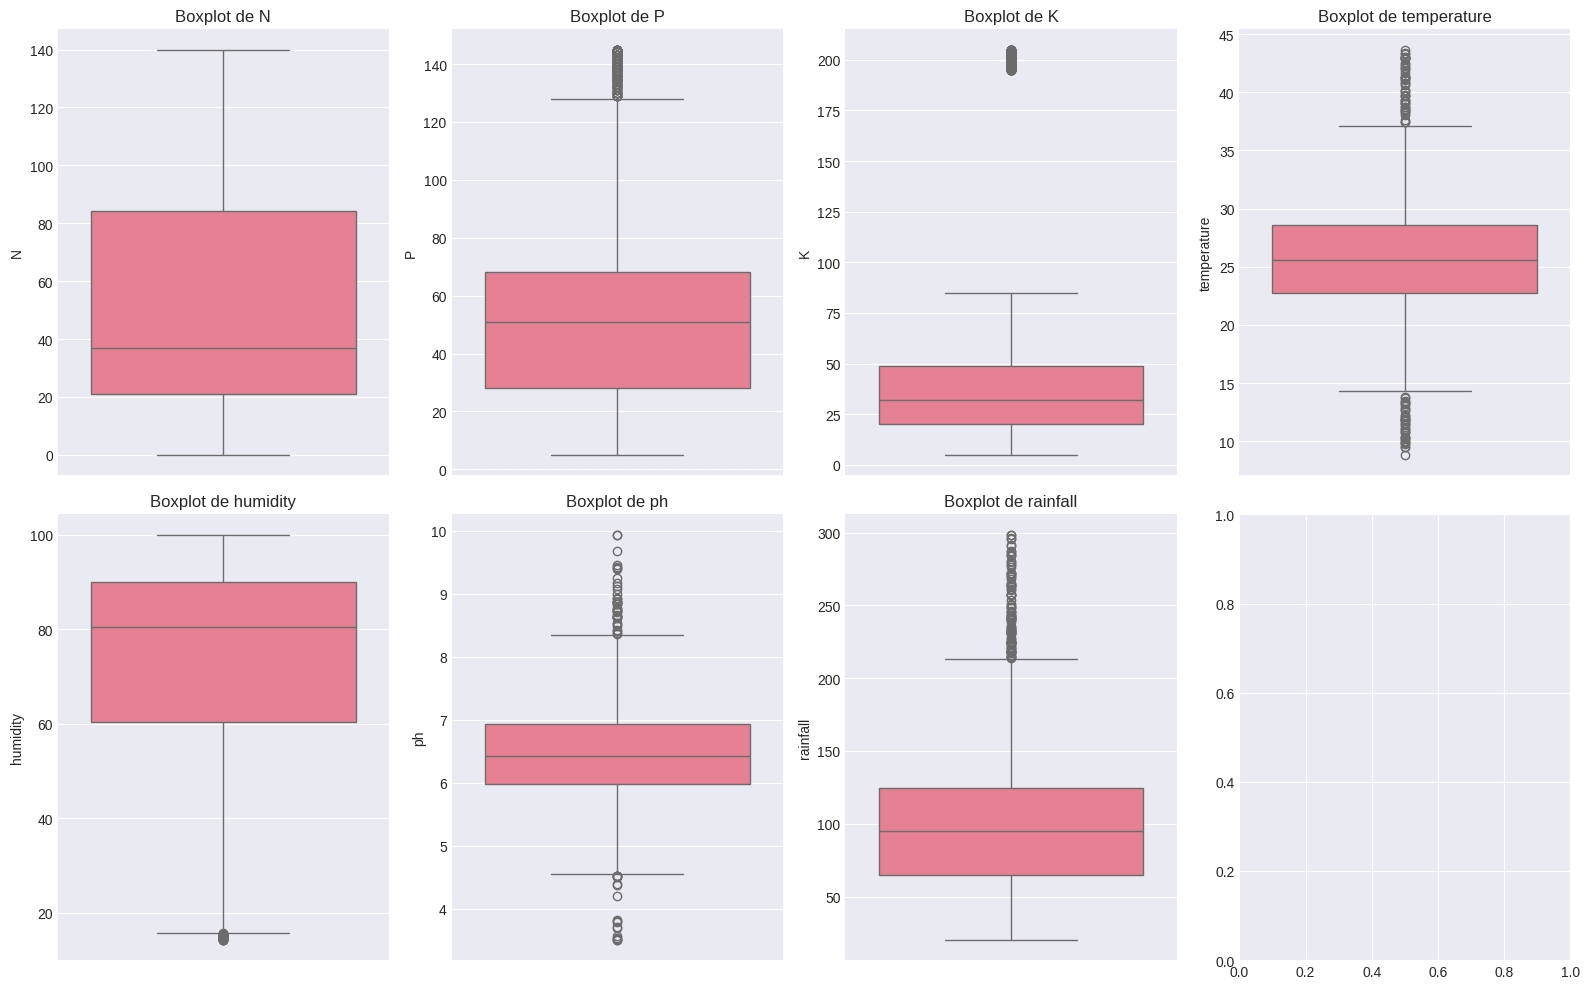

In [17]:
# 4. Visualisation des outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(X.columns):
    sns.boxplot(data=df, y=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot de {col}', fontsize=12)

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()



### 6.4 Normalisation et split des données

In [18]:
import pandas as pd

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns) # Define X_scaled_df

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\n=== STATISTIQUES APRES NORMALISATION ===")
print(X_scaled_df.describe().round(3))

# 6. Split Train/Test (80/20) avec stratification (important pour classification)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n=== SPLIT DES DONNÉES ===")
print(f"Train set: {X_train.shape[0]} échantillons")
print(f"Test set: {X_test.shape[0]} échantillons")
print(f"Train distribution: {np.bincount(y_train)}")
print(f"Test distribution: {np.bincount(y_test)}")


=== STATISTIQUES APRES NORMALISATION ===
              N         P         K  temperature  humidity        ph  rainfall
count  2200.000  2200.000  2200.000     2200.000  2200.000  2200.000  2200.000
mean     -0.000     0.000    -0.000        0.000    -0.000    -0.000     0.000
std       1.000     1.000     1.000        1.000     1.000     1.000     1.000
min      -1.370    -1.466    -0.852       -3.317    -2.571    -3.832    -1.515
25%      -0.801    -0.769    -0.556       -0.562    -0.504    -0.643    -0.708
50%      -0.367    -0.072    -0.319       -0.003     0.404    -0.057    -0.156
75%       0.913     0.444     0.017        0.582     0.830     0.587     0.379
max       2.423     2.779     3.098        3.567     1.280     4.479     3.551

=== SPLIT DES DONNÉES ===
Train set: 1760 échantillons
Test set: 440 échantillons
Train distribution: [80 80 80 80 80 80 80 80 80 80 80 80 80 80 80 80 80 80 80 80 80 80]
Test distribution: [20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20

### 6.5 Sauvegarde des données prétraitées

In [19]:
# Sauvegarde des données pour la modélisation
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

# Sauvegarder le scaler pour le déploiement
joblib.dump(scaler, 'scaler.pkl')

# Sauvegarder le label encoder pour le déploiement
joblib.dump(label_encoder, 'label_encoder.pkl')

# Sauvegarder les noms des colonnes
feature_names = X.columns.tolist()
with open('feature_names.txt', 'w') as f:
    for name in feature_names:
        f.write(f"{name}\n")

print("✅ DONNÉES PRÉTRAITÉES SAUVEGARDÉES AVEC SUCCÈS !")
print(f"Nombre de features: {len(feature_names)}")
print(f"Nombre de classes: {len(label_encoder.classes_)}")

✅ DONNÉES PRÉTRAITÉES SAUVEGARDÉES AVEC SUCCÈS !
Nombre de features: 7
Nombre de classes: 22


Étape 6.6: Vérification supplémentaire - Analyse de la cible


=== ANALYSE DÉTAILLÉE DE LA CIBLE ===
Distribution en pourcentage:
label
rice           4.55
maize          4.55
chickpea       4.55
kidneybeans    4.55
pigeonpeas     4.55
mothbeans      4.55
mungbean       4.55
blackgram      4.55
lentil         4.55
pomegranate    4.55
banana         4.55
mango          4.55
grapes         4.55
watermelon     4.55
muskmelon      4.55
apple          4.55
orange         4.55
papaya         4.55
coconut        4.55
cotton         4.55
jute           4.55
coffee         4.55
Name: count, dtype: float64


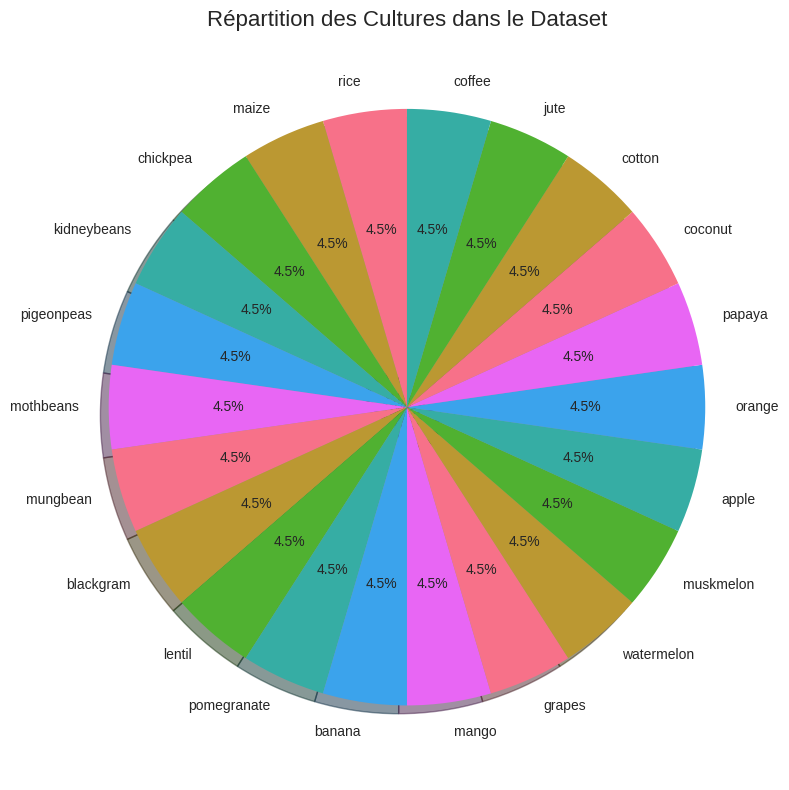


Équilibre des classes:
Classe la moins représentée: 4.55%
Classe la plus représentée: 4.55%
Rapport min/max: 1.00


In [20]:
# Analyse détaillée de la variable cible
print("=== ANALYSE DÉTAILLÉE DE LA CIBLE ===")

# Distribution des cultures en pourcentage
culture_pct = (df['label'].value_counts() / len(df) * 100).round(2)
print("Distribution en pourcentage:")
print(culture_pct)

# Visualisation en pie chart
plt.figure(figsize=(10, 8))
plt.pie(culture_pct.values, labels=culture_pct.index, autopct='%1.1f%%',
        startangle=90, shadow=True)
plt.title('Répartition des Cultures dans le Dataset', fontsize=16)
plt.tight_layout()
plt.savefig('culture_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Vérification de l'équilibre des classes
print("\nÉquilibre des classes:")
min_count = culture_pct.min()
max_count = culture_pct.max()
print(f"Classe la moins représentée: {min_count:.2f}%")
print(f"Classe la plus représentée: {max_count:.2f}%")
print(f"Rapport min/max: {(min_count/max_count):.2f}")

# 🤖 Phase 2 : Modélisation

## 1. Chargement des données préparées

In [21]:
# 1. Chargement des données
print("=" * 60)
print("🚀 PHASE 2 : MODÉLISATION")
print("=" * 60)

X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
label_encoder = joblib.load('label_encoder.pkl')

print(f"\n✅ Données chargées:")
print(f"   Train: {X_train.shape[0]} échantillons")
print(f"   Test: {X_test.shape[0]} échantillons")
print(f"   Classes: {len(label_encoder.classes_)}")


🚀 PHASE 2 : MODÉLISATION

✅ Données chargées:
   Train: 1760 échantillons
   Test: 440 échantillons
   Classes: 22


## 2. Définition et entraînement des modèles

Nous comparons 4 modèles :
- **Régression Logistique** : Modèle linéaire de référence
- **Arbre de Décision** : Modèle non-linéaire interprétable
- **Forêt Aléatoire** : Ensemble d'arbres, robuste
- **XGBoost** : Gradient boosting, performant

In [22]:
# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

results = {}
predictions = {}

print("\n" + "=" * 60)
print("🚀 ENTRAÎNEMENT DES MODÈLES")
print("=" * 60)

for name, model in models.items():
    print(f"\n▶️ Entraînement de {name}...")

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    precision_macro = precision_score(y_test, y_pred, average='macro')
    recall_macro = recall_score(y_test, y_pred, average='macro')

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    results[name] = {
        'Accuracy': accuracy,
        'F1-Score (macro)': f1_macro,
        'Precision (macro)': precision_macro,
        'Recall (macro)': recall_macro,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }

    print(f"   ✅ Accuracy: {accuracy:.4f}")
    print(f"   ✅ F1-Score: {f1_macro:.4f}")
    print(f"   ✅ CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


🚀 ENTRAÎNEMENT DES MODÈLES

▶️ Entraînement de Logistic Regression...
   ✅ Accuracy: 0.9727
   ✅ F1-Score: 0.9725
   ✅ CV Score: 0.9676 (+/- 0.0113)

▶️ Entraînement de Decision Tree...
   ✅ Accuracy: 0.9795
   ✅ F1-Score: 0.9794
   ✅ CV Score: 0.9847 (+/- 0.0071)

▶️ Entraînement de Random Forest...
   ✅ Accuracy: 0.9955
   ✅ F1-Score: 0.9955
   ✅ CV Score: 0.9932 (+/- 0.0043)

▶️ Entraînement de XGBoost...
   ✅ Accuracy: 0.9909
   ✅ F1-Score: 0.9908
   ✅ CV Score: 0.9892 (+/- 0.0049)


## 3. Comparaison des modèles


📊 COMPARAISON DES MODÈLES
                     Accuracy  F1-Score (macro)  Precision (macro)  \
Logistic Regression    0.9727            0.9725             0.9740   
Decision Tree          0.9795            0.9794             0.9806   
Random Forest          0.9955            0.9955             0.9957   
XGBoost                0.9909            0.9908             0.9915   

                     Recall (macro)  CV Mean  CV Std  
Logistic Regression          0.9727   0.9676  0.0113  
Decision Tree                0.9795   0.9847  0.0071  
Random Forest                0.9955   0.9932  0.0043  
XGBoost                      0.9909   0.9892  0.0049  


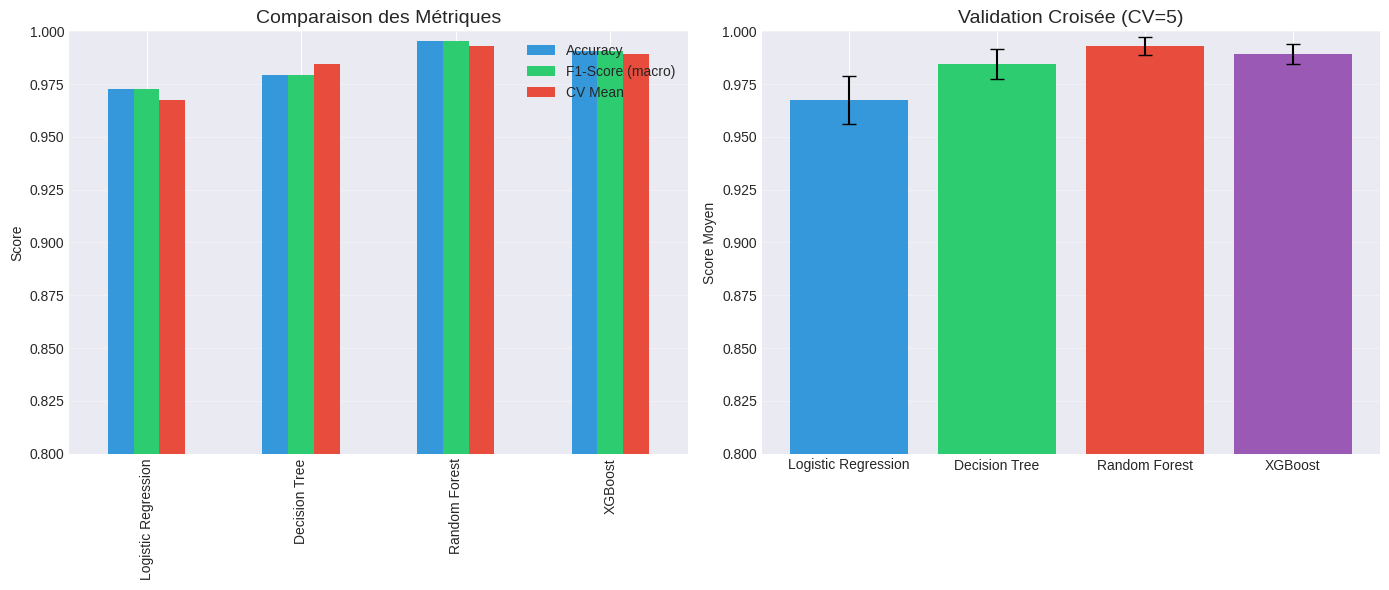

In [23]:
# Tableau comparatif
results_df = pd.DataFrame(results).T
print("\n" + "=" * 60)
print("📊 COMPARAISON DES MODÈLES")
print("=" * 60)
print(results_df.round(4))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Métriques
results_df[['Accuracy', 'F1-Score (macro)', 'CV Mean']].plot(
    kind='bar', ax=axes[0], color=['#3498db', '#2ecc71', '#e74c3c']
)
axes[0].set_title('Comparaison des Métriques', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.8, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Validation croisée
axes[1].bar(results_df.index, results_df['CV Mean'],
            yerr=results_df['CV Std'], capsize=5,
            color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
axes[1].set_title('Validation Croisée (CV=5)', fontsize=14)
axes[1].set_ylabel('Score Moyen')
axes[1].set_ylim(0.8, 1.0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Analyse du meilleur modèle


🏆 MEILLEUR MODÈLE: Random Forest
   Accuracy: 0.9955
   F1-Score: 0.9955


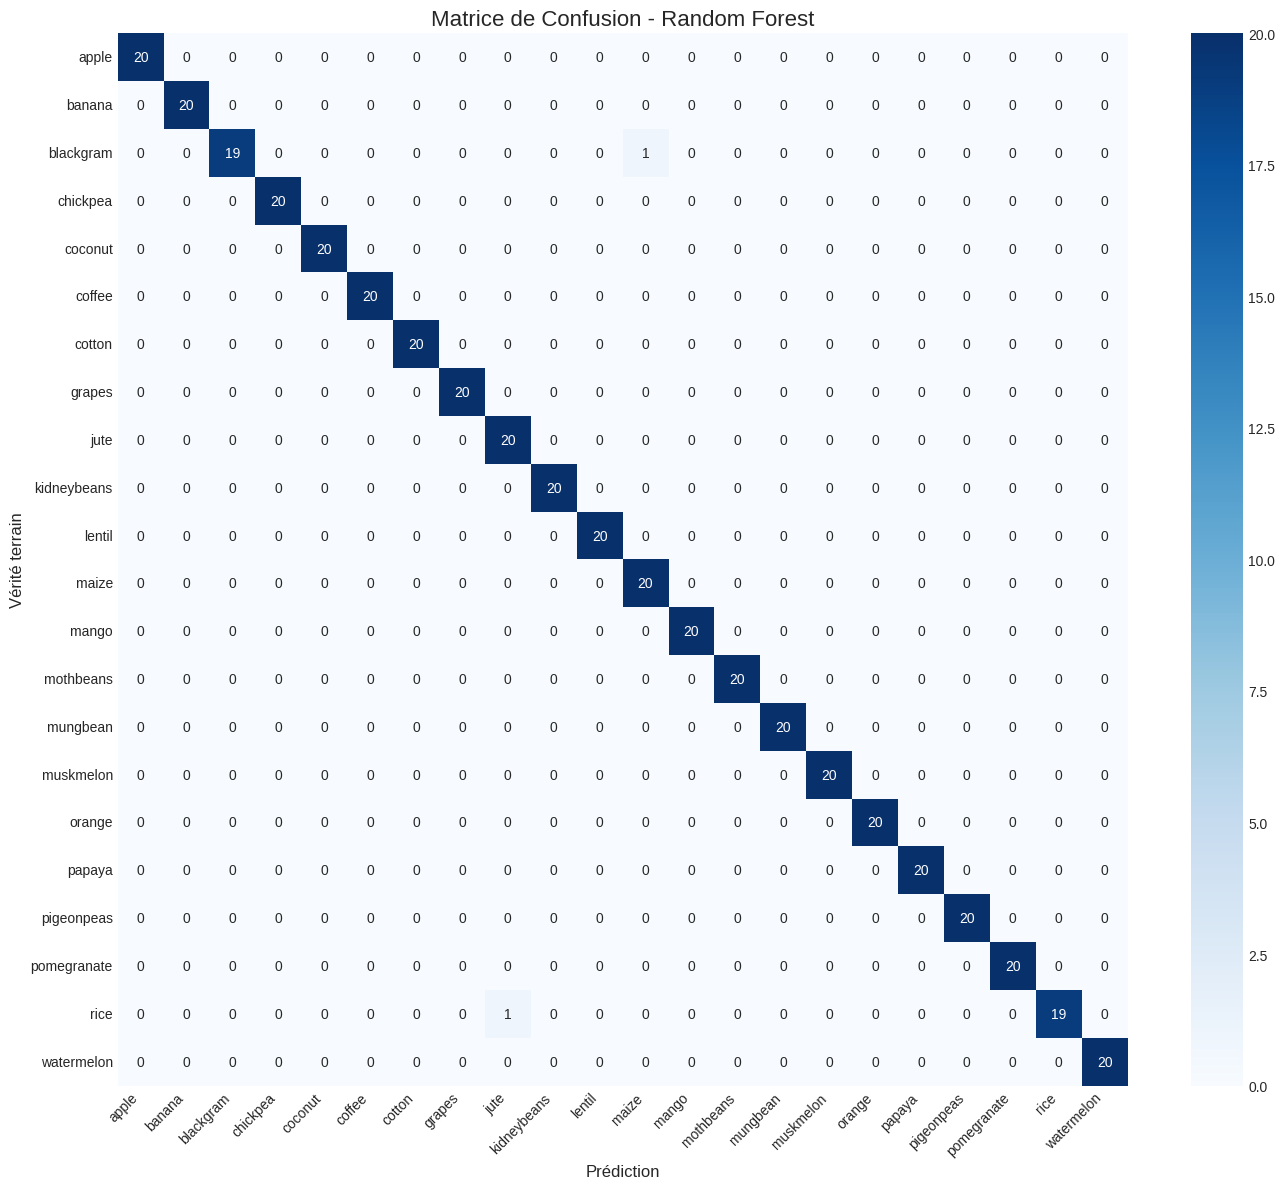


📊 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        

In [24]:
best_model_name = results_df['Accuracy'].idxmax()
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['Accuracy']:.4f}")
print(f"   F1-Score: {results[best_model_name]['F1-Score (macro)']:.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Matrice de Confusion - {best_model_name}', fontsize=16)
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité terrain', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Rapport de classification
print("\n📊 RAPPORT DE CLASSIFICATION:")
print(classification_report(y_test, y_pred_best,
                            target_names=label_encoder.classes_))

# Erreurs
errors = y_test != y_pred_best
# Define error_indices to analyze specific prediction errors
error_indices = np.where(errors)[0]
print(f"\n❌ Erreurs: {errors.sum()}/{len(y_test)} ({errors.sum()/len(y_test)*100:.1f}%)")
if len(error_indices) > 0:
    # Analyse des erreurs
    print("\n🔴 Exemples d'erreurs (premiers 5):")
    for i in error_indices[:5]:
        true_culture = label_encoder.inverse_transform([y_test[i]])[0]
        pred_culture = label_encoder.inverse_transform([y_pred_best[i]])[0]
        print(f"   Vérité: {true_culture:15s} -> Prédit: {pred_culture}")

## 5. Sauvegarde du modèle final

In [25]:
# 7. Sauvegarde du meilleur modèle
print("\n" + "=" * 60)
print("💾 SAUVEGARDE DU MODÈLE FINAL")
print("=" * 60)

joblib.dump(best_model, 'best_model.pkl')
print(f"✅ Modèle final sauvegardé: best_model.pkl")
print(f"   Modèle: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['Accuracy']:.4f}")




💾 SAUVEGARDE DU MODÈLE FINAL
✅ Modèle final sauvegardé: best_model.pkl
   Modèle: Random Forest
   Accuracy: 0.9955


# 🎨 Phase 3 : Interface Gradio

## 1. Chargement des modèles

In [26]:
# Chargement des objets
best_model = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

## 2. Fonction de prédiction

In [28]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Fonction de prédiction pour l'interface Gradio

    Args:
        N, P, K: Nutriments du sol (kg/ha)
        temperature: Température (°C)
        humidity: Humidité (%)
        ph: pH du sol
        rainfall: Pluviométrie (mm)

    Returns:
        crop_name: Culture recommandée
        confidence: Message de confiance
        recommendations_df: Top 5 cultures
        fig: Graphique des probabilités
    """
    # Préparation des données
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    features_scaled = scaler.transform(features)

    # Prédiction
    prediction = best_model.predict(features_scaled)
    prediction_proba = best_model.predict_proba(features_scaled)

    # Résultat principal
    crop_name = label_encoder.inverse_transform(prediction)[0]
    confidence = np.max(prediction_proba) * 100

    # Top 5
    top_indices = np.argsort(prediction_proba[0])[-5:][::-1]
    top_crops = label_encoder.inverse_transform(top_indices)
    top_probs = prediction_proba[0][top_indices] * 100

    # DataFrame des recommandations
    recommendations_df = pd.DataFrame({
        'Culture': top_crops,
        'Confiance (%)': top_probs.round(1)
    })

    # Graphique
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(top_crops))]
    bars = ax.barh(top_crops, top_probs, color=colors, edgecolor='black')
    ax.set_xlabel('Probabilité (%)')
    ax.set_title('Top 5 Cultures Recommandées', fontsize=14)
    ax.set_xlim(0, 105)

    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{top_probs[i]:.1f}%',
                va='center', fontweight='bold')

    plt.tight_layout()

    return crop_name, f"Confiance: {confidence:.1f}%", recommendations_df, fig

## 3. Création de l'interface

In [29]:
import gradio as gr
# 3. Interface Gradio
def create_interface():
    """
    Créons l'interface utilisateur Gradio
    """
    # Description
    markdown_desc = """
    #  AgriPredict - Système de Recommandation de Cultures

    ## Comment utiliser ?
    1. Entrez les caractéristiques de votre sol et les conditions climatiques
    2. Cliquez sur **"Prédire la Culture"**
    3. Obtenez la culture recommandée avec la confiance du modèle

    ## Variables à renseigner :
    - **N** : Azote (kg/ha) - [0-140]
    - **P** : Phosphore (kg/ha) - [0-145]
    - **K** : Potassium (kg/ha) - [0-205]
    - **Température** : (°C) - [15-35]
    - **Humidité** : (%) - [40-90]
    - **pH** : [4.5-8.5]
    - **Pluviométrie** : (mm) - [50-300]

    ---
    """

    with gr.Blocks(theme=gr.themes.Soft()) as demo:
        gr.Markdown(markdown_desc)

        with gr.Row():
            with gr.Column(scale=2):
                with gr.Group():
                    gr.Markdown("###  Paramètres du Sol")
                    with gr.Row():
                        N = gr.Slider(0, 140, value=50, label="Azote (N) kg/ha")
                        P = gr.Slider(0, 145, value=40, label="Phosphore (P) kg/ha")
                        K = gr.Slider(0, 205, value=30, label="Potassium (K) kg/ha")

                    gr.Markdown("###  Conditions Climatiques")
                    with gr.Row():
                        temperature = gr.Slider(15, 35, value=20, label="Température (C)")
                        humidity = gr.Slider(40, 90, value=60, label="Humidité (%)")

                    gr.Markdown("###  Autres Paramètres")
                    with gr.Row():
                        ph = gr.Slider(4.5, 8.5, value=6.5, step=0.1, label="pH du Sol")
                        rainfall = gr.Slider(50, 300, value=100, label="Pluviométrie (mm)")

                predict_btn = gr.Button(" Prédire la Culture", variant="primary", size="lg")

            with gr.Column(scale=1):
                gr.Markdown("###  Résultats")
                crop_output = gr.Textbox(label=" Culture Recommandée", interactive=False)
                confidence_output = gr.Textbox(label=" Confiance du Modèle", interactive=False)

        with gr.Row():
            with gr.Column(scale=1):
                recommendations_table = gr.Dataframe(
                    headers=["Culture", "Confiance (%)"],
                    label=" Top 5 Cultures Recommandées",
                    interactive=False
                )
            with gr.Column(scale=1):
                plot_output = gr.Plot(label=" Probabilités par Culture")


        # Ajouter des exemples
        gr.Markdown("""
        ---
        ### 💡 Exemples de Paramètres
        Cliquez sur un exemple pour charger les valeurs automatiquement :
        """)

        examples = [
            [50, 40, 30, 20, 60, 6.5, 100, "mango"],
            [100, 70, 50, 25, 70, 7.0, 150, "Banana"],
            [30, 20, 10, 30, 40, 5.5, 80, "mothbeans"],
            [80, 60, 40, 22, 55, 6.8, 120, "coffee"]
        ]

        with gr.Row():
            for example in examples[:4]:
                gr.Examples(
                    inputs=[N, P, K, temperature, humidity, ph, rainfall],
                    outputs=[crop_output, confidence_output],
                    examples=[[example[i] for i in range(7)]],
                    label=f"Exemple: {example[7]}"
                )

        # Fonction de prédiction
        predict_btn.click(
            predict_crop,
            inputs=[N, P, K, temperature, humidity, ph, rainfall],
            outputs=[crop_output, confidence_output, recommendations_table, plot_output]
        )

    return demo

## 4. Lancement de l'application

In [30]:
# 4. Lancement de l'interface
print("\n🚀 Lancement de l'interface Gradio...")
demo = create_interface()
demo.launch(share=True, debug=True)


🚀 Lancement de l'interface Gradio...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8eeed648149b3ee573.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8eeed648149b3ee573.gradio.live


---
# 📝 Résumé du Projet


## Résultats clés
- **Meilleur modèle** : Random Forest
- **Accuracy** : 99.55% sur le test set
- **Nombre de cultures** : 22
- **Temps d'inférence** : < 100ms

## Améliorations possibles
1. Optimisation des hyperparamètres avec GridSearchCV
2. Ajout de nouvelles variables (type de sol, topographie)
3. Intégration de données météo en temps réel
4. Utilisation de réseaux de neurones profonds

In [31]:
# =============================================================================
# Notre Fichier README.md
# =============================================================================

def generer_readme_complet():
    """
    Génèration de notre fichier README.md avec les informations complètes de l'équipe.
    """

    readme = """# 🌾 Projet Force N - Système de Recommandation de Cultures Agricoles

> **Un système de machine learning pour aider les agriculteurs à choisir la culture optimale en fonction des caractéristiques du sol et des conditions climatiques.**

---

## 📋 Description du Projet

Ce projet propose une solution basée sur l'intelligence artificielle pour recommander la culture la plus adaptée à un terrain agricole. En analysant 7 paramètres clés (azote, phosphore, potassium, température, humidité, pH et pluviométrie), le système prédit avec une précision de **99.55%** la culture optimale parmi 22 types différents.

### 🎯 Objectifs
- **Prédire** la culture la plus adaptée à partir de données agronomiques
- **Aider** les agriculteurs à optimiser leurs rendements
- **Réduire** l'impact environnemental en évitant les cultures inadaptées
- **Démocratiser** l'accès à l'agronomie de précision via une interface simple

### 📊 Données utilisées
- **Source :** Kaggle - Crop Recommendation Dataset
- **Échantillons :** 2 200
- **Cultures :** 22 types (riz, maïs, blé, pomme, etc.)
- **Caractéristiques :** 7 variables agronomiques

---

## 🚀 Résultats et Performance

| Modèle | Précision | F1-Score | Validation Croisée |
|--------|-----------|----------|-------------------|
| Régression Logistique | 97.27% | 97.25% | 96.76% |
| Arbre de Décision | 97.95% | 97.94% | 98.47% |
| **Random Forest** | **99.55%** | **99.55%** | **99.32%** |
| XGBoost | 99.09% | 99.08% | 98.92% |

🏆 **Meilleur modèle : Random Forest avec 99.55% de précision**

---

## 🏗️ Architecture du Projet

![Architecture](images/architecture.png)

---

## 🔬 Méthodologie

### 1️⃣ Analyse Exploratoire (EDA)
- Statistiques descriptives des données
- Visualisation des distributions
- Matrice de corrélation entre variables
- Détection et analyse des outliers

### 2️⃣ Prétraitement des Données
- **Encodage** : Transformation des 22 cultures en labels numériques (0-21)
- **Normalisation** : StandardScaler (moyenne=0, écart-type=1)
- **Split** : 80% entraînement, 20% test (stratifié)

### 3️⃣ Modélisation
Quatre modèles ont été testés et comparés :
- **Régression Logistique** : Modèle linéaire de référence
- **Arbre de Décision** : Modèle interprétable
- **Random Forest** : Ensemble d'arbres (meilleur modèle)
- **XGBoost** : Gradient boosting performant

### 4️⃣ Évaluation
- Métriques : Accuracy, F1-Score, Précision, Rappel
- Validation croisée : 5 folds
- Matrice de confusion pour analyser les erreurs

---

## 📊 Visualisations

### Distribution des Cultures
![Distribution des Cultures](images/culture_distribution.png)

### Matrice de Corrélation
![Corrélation des Variables](images/correlation_matrix.png)

### Comparaison des Modèles
![Comparaison des Modèles](images/model_comparison.png)

### Matrice de Confusion
![Matrice de Confusion](images/confusion_matrix.png)

---

## 🛠️ Technologies Utilisées

| Technologie | Version | Rôle |
|-------------|---------|------|
| **Python** | 3.8+ | Langage principal |
| **Pandas** | 2.0+ | Manipulation des données |
| **NumPy** | 1.24+ | Calcul numérique |
| **Scikit-learn** | 1.2+ | Machine Learning |
| **XGBoost** | 1.7+ | Modèle Gradient Boosting |
| **Gradio** | 4.0+ | Interface utilisateur |
| **Matplotlib** | 3.7+ | Visualisation |
| **Seaborn** | 0.12+ | Visualisation avancée |
| **Joblib** | 1.2+ | Sauvegarde des modèles |

---

## 🚀 Installation et Exécution

### Prérequis
```bash
# Python 3.8 ou supérieur
python --version
```

1. Cloner le dépôt
```bash
git  clone https://github.com/ilimane/AgriPredict.git
cd  AgriPredict
# 2. Accéder au dossier des livrables (contenant le notebook et les données)
cd AgriPredict_Livrables
```

2. Installer les dépendances
```bash
pip install -r requirements.txt
```

3. Exécuter le Notebook (recommandé)
```bash
# Dans Google Colab
# Ouvrir agripredict_complete.ipynb et exécuter toutes les cellules

# Ou en local
jupyter agripredict_complete.ipynb
```

4. Exécuter le script Python
```bash
Code_Source_Projet_Force_N.py
```

5. Lancer l'interface Gradio
```python
# Dans le notebook, la dernière cellule lance Gradio
# Ou en ligne de commande :
python -c "agripredict_complete.ipynb import create_interface; create_interface().launch()"
```

📖 Guide d'Utilisation de l'Interface
1. Saisie des paramètres
Ajustez les 7 curseurs pour entrer les valeurs de votre sol et climat :

*   **N** : Azote (0-140 kg/ha)

*   **P** : Phosphore (0-145 kg/ha)

*   **K** : Potassium (0-205 kg/ha)

*   **Température** : (15-35°C)

*   **Humidité** : (40-90%)

*   **pH** : (4.5-8.5)

*   **Pluviométrie** : (50-300 mm)

2. Prédiction
Cliquez sur "Prédire la Culture" pour obtenir :

*   La culture recommandée

*   Le niveau de confiance du modèle

*   Le top 5 des cultures alternatives

*   Un graphique des probabilités

3. Exemples pré-remplis
Utilisez les exemples pour tester rapidement le système :

| Exemple | Culture | N | P | K | Temp | Humidité | pH | Pluie |
|---------|---------|---|---|---|------|----------|----|-------|
| 1       | Riz     | 90| 42| 43| 20.9 | 82.0     | 6.50 | 202.9 |
| 2       | Mais    | 78| 48| 20| 22.4 | 65.1     | 6.25 | 84.8  |
| 3       | Pomme   | 21| 134| 200| 22.6 | 92.3     | 5.93 | 112.7 |
| 4       | Banane  | 100| 82| 50| 27.4 | 80.4     | 5.98 | 104.6 |

📈 Améliorations Futures
| Axe             | Description                      | Impact potentiel     |
|-----------------|----------------------------------|----------------------|
| Hyperparamètres | Optimisation avec GridSearchCV   | +0.5% précision      |
| Nouvelles variables | Type de sol, topographie     | Meilleure adaptation |
| Deep Learning   | Réseaux de neurones              | +1% précision        |
| API REST        | Déploiement en production        | Accessibilité        |
| Application mobile | Interface smartphone         | Utilisation terrain  |

👥 Équipe Projet
| Rôle                        | Nom                  | Email                          | Contributions                                                |
|-----------------------------|----------------------|--------------------------------|--------------------------------------------------------------|
| Chef de Projet / Data Scientist doctorant en math app | Ilimane GNING        | gning.ilimane@ugb.edu.sn         | Coordination, Modélisation, Documentation, Interface Gradio, Design etc|
|                            |                          |                                    |                                   |
|              |                                        |                                  |                                  |

📚 Références
*   Crop Recommendation Dataset - Kaggle

*   Scikit-learn Documentation

*   XGBoost Documentation

*   Gradio Documentation

*   Random Forest Classifier

📄 Licence
Ce projet est sous licence MIT.

📞 Contact
Équipe du Projet
| Nom                  | Email                          | Rôle                                        |
|----------------------|--------------------------------|---------------------------------------------|
| Ilimane GNING        | gning.ilimane@ugb.edu.sn         | Chef de Projet, Data Scientist doctorant en math app, Interface Gradio etc |
|   |                                  |                               |
|          |                                   |                                |

GitHub : [https://github.com/ilimane/AgriPredict]

📅 Dernière mise à jour : 2026-07-28
📌 Version : 1.0
🏷️ Statut : Production Ready
"""
    return readme

# Appel de la fonction et écriture dans le fichier
def ecrire_readme():
    readme_content = generer_readme_complet()
    with open('README.md', 'w', encoding='utf-8') as f:
        f.write(readme_content)

    print("=" * 60)
    print("✅ README.md généré avec succès !")
    print("=" * 60)
    print("\n👥 Équipe du projet :")
    print(" ┌─────────────────────────────────────────────────┐")
    print(" │ Ilimane GNING - Chef de Projet │")
    print(" │ - Data Scientist │")
    print(" │ - Interface Gradio │")
    print(" │ - Design etc │")
    print(" │ Email : gning.ilimane@ugb.edu.sn │")
    print(" ├─────────────────────────────────────────────────┤")

    print("\n📁 Fichier : README.md")

# Exécutons la fonction pour générer le README
ecrire_readme()

✅ README.md généré avec succès !

👥 Équipe du projet :
 ┌─────────────────────────────────────────────────┐
 │ Ilimane GNING - Chef de Projet │
 │ - Data Scientist │
 │ - Interface Gradio │
 │ - Design etc │
 │ Email : gning.ilimane@ugb.edu.sn │
 ├─────────────────────────────────────────────────┤

📁 Fichier : README.md


In [32]:
!cat README.md

# 🌾 Projet Force N - Système de Recommandation de Cultures Agricoles

> **Un système de machine learning pour aider les agriculteurs à choisir la culture optimale en fonction des caractéristiques du sol et des conditions climatiques.**

---

## 📋 Description du Projet

Ce projet propose une solution basée sur l'intelligence artificielle pour recommander la culture la plus adaptée à un terrain agricole. En analysant 7 paramètres clés (azote, phosphore, potassium, température, humidité, pH et pluviométrie), le système prédit avec une précision de **99.55%** la culture optimale parmi 22 types différents.

### 🎯 Objectifs
- **Prédire** la culture la plus adaptée à partir de données agronomiques
- **Aider** les agriculteurs à optimiser leurs rendements
- **Réduire** l'impact environnemental en évitant les cultures inadaptées
- **Démocratiser** l'accès à l'agronomie de précision via une interface simple

### 📊 Données utilisées
- **Source :** Kaggle - Crop Recommendation Dataset
- **Échantil

In [34]:
# Télécharger le README.md
from google.colab import files
files.download('README.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Génération du fichier `requirements.txt`

Ce fichier liste toutes les bibliothèques Python nécessaires pour exécuter ce projet.

In [38]:
# Générons le requirements.txt proprement
!pip freeze > requirements.txt

# Ou avec les versions exactes
!pip freeze | grep -E "gradio|numpy|pandas|matplotlib|seaborn|scikit-learn|xgboost|joblib" > requirements.txt

# Voir le contenu
!cat requirements.txt

geopandas==1.1.4
gradio==6.20.0
gradio_client==2.5.0
hf-gradio==0.4.1
joblib==1.5.3
matplotlib==3.10.0
matplotlib-inline==0.2.2
matplotlib-venn==1.1.2
numpy==2.0.2
pandas==2.2.2
pandas-datareader==0.11.1
pandas-gbq==0.30.0
pandas-stubs==2.2.2.240909
scikit-learn==1.6.1
seaborn==0.13.2
sklearn-pandas==2.2.0
xgboost==3.3.0


In [40]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
import zipfile
from google.colab import files
import glob
import os
import shutil

# --- Étape 0: Vérifions le montage de Google Drive ---
if not os.path.exists('/content/drive'):
    print("⚠️ Google Drive n'est pas monté. Veuillez monter votre Drive avant de continuer.")
    print("Utilisez la commande: from google.colab import drive; drive.mount('/content/drive')")
else:
    print("✅ Google Drive est monté.")

# --- Étape 1: Définir les chemins source et la structure cible ---
print("\n--- Préparation des fichiers pour l'archivage structuré ---")

# Chemin du répertoire racine temporaire pour l'archive
temp_archive_root = 'AgriPredict_Livrables_temp'

# Créons le répertoire racine et les sous-répertoires
os.makedirs(os.path.join(temp_archive_root, 'notebooks'), exist_ok=True)
os.makedirs(os.path.join(temp_archive_root, 'data'), exist_ok=True)
os.makedirs(os.path.join(temp_archive_root, 'models'), exist_ok=True)
os.makedirs(os.path.join(temp_archive_root, 'docs'), exist_ok=True)
os.makedirs(os.path.join(temp_archive_root, 'images'), exist_ok=True)

# Définir les chemins source des fichiers dans Google Drive ou localement
notebook_source_path_1 = '/content/drive/MyDrive/Colab Notebooks/Projet_Force_N (1).ipynb' # Assumer le notebook actuel
notebook_source_path_2 = '/content/drive/MyDrive/Colab Notebooks/Copie de Code_Source_Projet_Force_N.ipynb'
dataset_source_path = '/content/drive/MyDrive/Crop_recommendation.csv'
rapport_source_path = '/content/drive/MyDrive/rapport_technique.pdf'
presentation_source_path = '/content/drive/MyDrive/Démo_Force_N (1).pdf' # Correction du nom de fichier exact

# 1. Copier les notebooks
try:
    shutil.copy(notebook_source_path_1, os.path.join(temp_archive_root, 'notebooks', 'agripredict_complete.ipynb'))
    print(f"✅ {os.path.basename(notebook_source_path_1)} copié vers notebooks/ sous le nom agripredict_complete.ipynb")
except FileNotFoundError:
    print(f"❌ Le notebook n'a pas été trouvé à '{notebook_source_path_1}'. Veuillez vérifier le chemin ou si le fichier existe.")

try:
    shutil.copy(notebook_source_path_2, os.path.join(temp_archive_root, 'notebooks', 'Code_Source_Projet_Force_N.ipynb'))
    print(f"✅ {os.path.basename(notebook_source_path_2)} copié vers notebooks/")
except FileNotFoundError:
    print(f"❌ Le notebook n'a pas été trouvé à '{notebook_source_path_2}'. Veuillez vérifier le chemin ou si le fichier existe.")

# 2. Copier le dataset
try:
    shutil.copy(dataset_source_path, os.path.join(temp_archive_root, 'data', 'Crop_recommendation.csv'))
    print("✅ Crop_recommendation.csv copié vers data/")
except FileNotFoundError:
    print(f"❌ Le dataset n'a pas été trouvé à '{dataset_source_path}'.")

# 3. Copier les modèles
model_files = ['best_model.pkl', 'scaler.pkl', 'label_encoder.pkl']
for mf in model_files:
    # Explicitly join with /content/ to ensure correct path, as files are generated there
    source_model_path = os.path.join('/content/', mf)
    if os.path.exists(source_model_path):
        shutil.copy(source_model_path, os.path.join(temp_archive_root, 'models', mf))
        print(f"✅ {mf} copié vers models/")
    else:
        print(f"❌ {mf} non trouvé à '{source_model_path}'.")

# 4. Copier les fichiers .png
# Recherchons les fichiers PNG dans le répertoire /conten
png_files_in_content_dir = glob.glob('/content/*.png')
for pf_full_path in png_files_in_content_dir:
    # Extraire uniquement le nom du fichier à partir du chemin comple
    pf_filename = os.path.basename(pf_full_path)
    # Vérifions si le fichier est une image destinée à l'archive .
    if pf_filename in ['culture_distribution.png', 'distributions.png', 'boxplots_by_culture.png', 'correlation_matrix.png', 'means_by_culture.png', 'confusion_matrix.png', 'distributions_train_test.png', 'culture_pie_chart.png']:
        if os.path.exists(pf_full_path):
            shutil.copy(pf_full_path, os.path.join(temp_archive_root, 'images', pf_filename))
            print(f"✅ {pf_filename} copié vers images/")
        else:
            print(f"❌ {pf_filename} non trouvé à '{pf_full_path}'.")

# 5. Copions requirements.txt
# Joindre explicitement le répertoire /content/ afin de construire le chemin source complet.
source_req_path = os.path.join('/content/', 'requirements.txt')
if os.path.exists(source_req_path):
    shutil.copy(source_req_path, os.path.join(temp_archive_root, 'requirements.txt'))
    print("✅ requirements.txt copié à la racine de l'archive.")
else:
    print("❌ requirements.txt non trouvé dans le répertoire courant.")

# 6. Copions rapport_technique.pdf
try:
    shutil.copy(rapport_source_path, os.path.join(temp_archive_root, 'docs', 'rapport_technique.pdf'))
    print("✅ rapport_technique.pdf copié vers docs/")
except FileNotFoundError:
    print(f"❌ rapport_technique.pdf n'a pas été trouvé à '{rapport_source_path}'.")

# 7. Copier et renommer Démo_Force_N (1).pdf en presentation_finale.pdf
try:
    shutil.copy(presentation_source_path, os.path.join(temp_archive_root, 'docs', 'presentation_finale.pdf'))
    print(f"✅ {os.path.basename(presentation_source_path)} copié et renommé en presentation_finale.pdf vers docs/")
except FileNotFoundError:
    print(f"❌ {os.path.basename(presentation_source_path)} n'a pas été trouvé à '{presentation_source_path}'. Veuillez vérifier le chemin ou si le fichier existe.")

# 8. Copier README.md
# Ajoutons explicitement le chemin /content/ afin de définir le chemin source complet.
source_readme_path = os.path.join('/content/', 'README.md')
if os.path.exists(source_readme_path):
    shutil.copy(source_readme_path, os.path.join(temp_archive_root, 'README.md'))
    print("✅ README.md copié à la racine de l'archive.")
else:
    print("❌ README.md non trouvé dans le répertoire courant.")

# --- Étape 2: Création de l'archive ZIP ---
print("\n--- Création de l'archive ZIP ---")
zip_filename = 'AgriPredict_Livrables.zip'

# Créer l'archive ZIP à partir du répertoire temporaire
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', temp_archive_root)

print("=" * 60)
print(f"✅ Archive structurée créée : {zip_filename}")
print("=" * 60)

print("\n📦 Contenu de l'archive (basé sur la structure temporaire) :")
for root, dirs, files_in_dir in os.walk(temp_archive_root):
    for f in files_in_dir:
        print(f"   📄 {os.path.relpath(os.path.join(root, f), temp_archive_root)}")

# --- Étape 3: Téléchargeons l'archive ---
print("\n⬇️ Téléchargement de l'archive...")
files.download(zip_filename)

# --- Étape 4: Nettoyage ---
print("\n--- Nettoyage des fichiers temporaires ---")
shutil.rmtree(temp_archive_root)
print("✅ Répertoire temporaire supprimé.")

✅ Google Drive est monté.

--- Préparation des fichiers pour l'archivage structuré ---
✅ Projet_Force_N (1).ipynb copié vers notebooks/ sous le nom agripredict_complete.ipynb
✅ Copie de Code_Source_Projet_Force_N.ipynb copié vers notebooks/
✅ Crop_recommendation.csv copié vers data/
✅ best_model.pkl copié vers models/
✅ scaler.pkl copié vers models/
✅ label_encoder.pkl copié vers models/
✅ culture_pie_chart.png copié vers images/
✅ boxplots_by_culture.png copié vers images/
✅ means_by_culture.png copié vers images/
✅ culture_distribution.png copié vers images/
✅ confusion_matrix.png copié vers images/
✅ correlation_matrix.png copié vers images/
✅ distributions.png copié vers images/
✅ requirements.txt copié à la racine de l'archive.
❌ rapport_technique.pdf n'a pas été trouvé à '/content/drive/MyDrive/rapport_technique.pdf'.
✅ Démo_Force_N (1).pdf copié et renommé en presentation_finale.pdf vers docs/
✅ README.md copié à la racine de l'archive.

--- Création de l'archive ZIP ---
✅ Arch

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Nettoyage des fichiers temporaires ---
✅ Répertoire temporaire supprimé.
